# Библиотеки и файлы

In [ ]:
# advanced_tfidf_pipeline.py
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
from tqdm import tqdm
from nltk.corpus import stopwords
import nltk
from google.colab import files

In [ ]:
!pip install pymorphy2
import pymorphy2


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 85.8 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=07219112da9a4963c73b6271cd2b5e063c981b7289e3aa38eca025f76f92e9a5
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive') #вылезет регистрация
# Путь к папке с ноутбуком
notebook_path = '/content/drive/MyDrive/My programming edu/LLM stepik'
questions_df = pd.read_csv(os.path.join(notebook_path, 'questions_clean.csv'))
websites_df = pd.read_csv(os.path.join(notebook_path, 'websites_updated.csv'))
df2 = pd.read_csv(os.path.join(notebook_path, 'sample_submission.csv'))

Mounted at /content/drive


In [ ]:

questions_df.head(5)

,q_id,query
0,1,Номер счета
1,2,Где узнать бик и счёт
2,3,Мне не приходят коды для подтверждения данной ...
3,4,"Оформила рассрочку ,но уведомлений никаких не ..."
4,5,"Здравствуйте, когда смогу пользоваться кредитн..."


In [ ]:
websites_df.head(5)

,web_id,url,kind,title,text
0,1,https://alfabank.ru/,html,"Альфа-Банк - кредитные и дебетовые карты, кред...",Рассчитайте выгоду\nРасчёт калькулятора предва...
1,2,https://alfabank.ru/a-club/,html,А-Клуб. Деньги имеют значение,Брокерские услуги\nОткрытие брокерского счёта ...
2,3,https://alfabank.ru/a-club/ultimate/,html,А-Клуб. Деньги имеют значение,Хотите получить больше информации?\nПозвоните ...
3,4,https://alfabank.ru/actions/rules/,html,Скидки по картам,Правила проведения Акции «Альфа Пятница. Бараб...
4,5,https://alfabank.ru/alfafuture/,html,Альфа‑Будущее: Платформа для развития студенто...,Образование\nМагистратуры\nМагистратура ВШЭ\nМ...


In [ ]:
df2.head(5)

,q_id,web_list
0,1,"[935, 687, 963, 1893, 1885]"
1,2,"[1660, 1882, 1040, 1090, 64]"
2,3,"[1246, 698, 465, 757, 307]"
3,4,"[366, 1625, 461, 279, 678]"
4,5,"[898, 589, 1162, 1889, 1181]"


# TF-IDF + Cosine Similarity

## Classes


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
from tqdm import tqdm

In [ ]:
class TFIDFRetriever:
    def __init__(self):
        self.vectorizer = TfidfVectorizer(
            lowercase=True,
            max_features=20000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.8
        )
        self.tfidf_matrix = None
        self.document_ids = None
        self.question_ids = None

    def preprocess_text(self, text):
        """Предобработка текста"""
        if pd.isna(text):
            return ""
        text = str(text).lower()
        # Удаляем HTML-теги
        text = re.sub(r'<[^>]+>', '', text)
        # Удаляем спецсимволы, но оставляем буквы, цифры и пробелы
        text = re.sub(r'[^\w\s]', ' ', text)
        # Заменяем множественные пробелы на один
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def prepare_documents(self, websites_df):
        """Подготовка документов из Websites.csv"""
        print("Подготовка документов...")
        documents = []
        self.document_ids = []

        for _, row in tqdm(websites_df.iterrows(), total=len(websites_df)):
            # Объединяем title и text для лучшего качества
            doc_text = f"{row['title']} {row['text']}"
            processed_doc = self.preprocess_text(doc_text)
            documents.append(processed_doc)
            self.document_ids.append(row['web_id'])

        return documents

    def prepare_queries(self, questions_df):
        """Подготовка вопросов из Questions.csv"""
        print("Подготовка вопросов...")
        queries = []
        self.question_ids = []

        for _, row in tqdm(questions_df.iterrows(), total=len(questions_df)):
            processed_query = self.preprocess_text(row['query'])
            queries.append(processed_query)
            self.question_ids.append(row['q_id'])

        return queries

    def fit(self, documents):
        """Обучение TF-IDF на документах"""
        print("Обучение TF-IDF модели...")
        self.tfidf_matrix = self.vectorizer.fit_transform(documents)
        print(f"Размерность матрицы: {self.tfidf_matrix.shape}")
        return self

    def search(self, queries, k=5):
        """Поиск k ближайших документов для всех запросов"""
        print("Поиск релевантных документов...")

        # Векторизуем все запросы
        query_vectors = self.vectorizer.transform(queries)

        # Вычисляем косинусную схожесть для всех запросов сразу
        similarities = cosine_similarity(query_vectors, self.tfidf_matrix)

        results = []
        for i, similarity_row in enumerate(tqdm(similarities, total=len(queries))):
            # Получаем индексы топ-k документов
            top_k_indices = np.argsort(similarity_row)[-k:][::-1]

            # Получаем ID документов
            top_k_doc_ids = [str(self.document_ids[idx]) for idx in top_k_indices]

            # Форматируем в строку через пробел
            web_list = ' '.join(top_k_doc_ids)

            results.append({
                'q_id': self.question_ids[i],
                'web_list': web_list
            })

        return results


In [ ]:
class AdvancedTFIDFRetriever(TFIDFRetriever):
    def __init__(self, use_lemmatization=True, use_stopwords=True, remove_numbers=False, remove_single_chars=True):
        super().__init__()
        self.use_lemmatization = use_lemmatization
        self.use_stopwords = use_stopwords
        self.remove_numbers = remove_numbers
        self.remove_single_chars = remove_single_chars

        # Инициализация лемматизатора
        if use_lemmatization:
            print("Инициализация лемматизатора pymorphy2...")
            self.morph = pymorphy2.MorphAnalyzer()

        # Загрузка стоп-слов
        if use_stopwords:
            try:
                self.stop_words = set(stopwords.words('russian'))
                # Расширяем список стоп-слов для банковской тематики
                additional_stopwords = {
                    'альфа', 'банк', 'банка', 'банку', 'банком',
                    'ооо', 'зао', 'ао', 'www', 'com', 'руб', 'рублей'
                }
                self.stop_words.update(additional_stopwords)
                print(f"Загружено стоп-слов: {len(self.stop_words)}")
            except Exception as e:
                print(f"Ошибка загрузки стоп-слов: {e}")
                self._create_backup_stopwords()

        # Улучшенный векторцайзер
        self.vectorizer = TfidfVectorizer(
            lowercase=True,  # Уже делаем в предобработке, но для надежности
            max_features=25000,
            ngram_range=(1, 3),
            min_df=2,
            max_df=0.75,
            stop_words=None  # Стоп-слова удаляем в предобработке
        )

    def _create_backup_stopwords(self):
        """Создание резервного списка стоп-слов"""
        basic_stopwords = ['здравствуйте', 'подскажите', 'можно', 'и', 'в', 'во', 'что', 'он', 'на', 'я', 'с', 'со', 'а', 'то',
                          'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по',
                          'только', 'ее', 'мне', 'вот', 'от', 'меня', 'еще', 'о', 'из', 'ему']
        self.stop_words = set(basic_stopwords)

    def preprocess_text(self, text):
        """Улучшенная предобработка текста со всеми рекомендованными методами"""
        if pd.isna(text):
            return ""

        # 1. Приведение к строковому типу
        text = str(text)

        # 2. Приведение к нижнему регистру
        text = text.lower()

        # 3. Удаление HTML-тегов и специальных символов
        text = re.sub(r'<[^>]+>', '', text)  # HTML теги
        text = re.sub(r'&[a-z]+;', '', text)  # HTML entities

        # 4. Удаление URL и email адресов
        #text = re.sub(r'http\S+', '', text)  # URL
        #text = re.sub(r'www\.\S+', '', text) # www ссылки
        #text = re.sub(r'\S+@\S+', '', text)  # email

        # 5. Удаление пунктуации и специальных символов
        text = re.sub(r'[^\w\s]', ' ', text)

        # 6. Удаление чисел (опционально)
        #if self.remove_numbers:
         #   text = re.sub(r'\d+', '', text)

        # 7. Удаление одиночных символов (опционально)
        #if self.remove_single_chars:
        #    text = re.sub(r'\b\w\b', ' ', text)

        # 8. Нормализация пробелов
        text = re.sub(r'\s+', ' ', text)  # Множественные пробелы → один
        text = text.strip()  # Пробелы в начале/конце

        # 9. Удаление стоп-слов
        if self.use_stopwords and hasattr(self, 'stop_words') and text:
            words = text.split()
            filtered_words = [word for word in words if word not in self.stop_words and len(word) > 1]
            text = ' '.join(filtered_words)

        # 10. Лемматизация (если включена)
        if self.use_lemmatization and text:
            text = self.lemmatize_text(text)

        return text

    def lemmatize_text(self, text):
        """Лемматизация текста с улучшенной обработкой"""
        words = text.split()
        lemmatized_words = []

        for word in words:
            # Пропускаем короткие слова и числа
            if len(word) <= 1 or word.isdigit():
                lemmatized_words.append(word)
                continue

            try:
                parsed_word = self.morph.parse(word)[0]
                normal_form = parsed_word.normal_form
                # Используем лемму только если она отличается от исходного слова
                # и не является стоп-словом
                if (normal_form != word and
                    not (self.use_stopwords and normal_form in self.stop_words)):
                    lemmatized_words.append(normal_form)
                else:
                    lemmatized_words.append(word)
            except Exception:
                # В случае ошибки оставляем исходное слово
                lemmatized_words.append(word)

        return ' '.join(lemmatized_words)

    def prepare_documents(self, websites_df, use_title=True, title_weight=2):
        """Улучшенная подготовка документов с весами для заголовков"""
        print("Подготовка документов с расширенной обработкой...")
        documents = []
        self.document_ids = []

        for _, row in tqdm(websites_df.iterrows(), total=len(websites_df)):
            # Обрабатываем заголовок и текст отдельно
            title_processed = self.preprocess_text(row['title'])
            text_processed = self.preprocess_text(row['text'])

            # Усиливаем заголовок повторением
            if use_title and title_processed:
                weighted_title = ' '.join([title_processed] * title_weight)
                doc_text = f"{weighted_title} {text_processed}"
            else:
                doc_text = f"{title_processed} {text_processed}"

            # Финализируем обработку
            final_doc = self.preprocess_text(doc_text)  # На случай если появятся новые стоп-слова

            documents.append(final_doc)
            self.document_ids.append(row['web_id'])

        # Удаляем пустые документы
        non_empty_docs = []
        non_empty_ids = []
        #for doc, doc_id in zip(documents, self.document_ids):
            #if doc and len(doc.strip()) > 10:  # Минимум 10 символов
                #non_empty_docs.append(doc)
                #non_empty_ids.append(doc_id)

        print(f"После очистки осталось документов: {len(non_empty_docs)}/{len(documents)}")
        documents = non_empty_docs
        self.document_ids = non_empty_ids

        return documents

In [ ]:

"""Основная функция пайплайна"""
print(f"Загружено вопросов: {len(questions_df)}")
print(f"Загружено документов: {len(websites_df)}")

# 2. Инициализация и подготовка данных
retriever = TFIDFRetriever()

# Подготовка документов
documents = retriever.prepare_documents(websites_df)

# Подготовка вопросов
queries = retriever.prepare_queries(questions_df)

# 3. Обучение модели
retriever.fit(documents)

# 4. Поиск релевантных документов
results = retriever.search(queries, k=5)

# 5. Создание сабмит файла
submit_df = pd.DataFrame(results)
submit_df = submit_df[['q_id', 'web_list']]  # Правильный порядок колонок

# Сохранение результата
submit_df.to_csv('submit.csv', index=False)
print("Файл submit.csv успешно создан!")
print(f"Обработано вопросов: {len(submit_df)}")

# Пример результата
print("\nПример строк из submit.csv:")
print(submit_df.head(3))

Загружено вопросов: 6977
Загружено документов: 1938
Подготовка документов...


100%|██████████| 1938/1938 [00:02<00:00, 732.85it/s]


Подготовка вопросов...


100%|██████████| 6977/6977 [00:01<00:00, 4213.41it/s]


Обучение TF-IDF модели...
Размерность матрицы: (1938, 20000)
Поиск релевантных документов...


100%|██████████| 6977/6977 [00:02<00:00, 3190.45it/s]


Файл submit.csv успешно создан!
Обработано вопросов: 6977

Пример строк из submit.csv:
   q_id               web_list
0     1  135 1567 108 1607 893
1     2  368 372 862 1570 1113
2     3  412 1733 128 411 1175


In [ ]:
submit_df

,q_id,web_list
0,1,135 1567 108 1607 893
1,2,368 372 862 1570 1113
2,3,412 1733 128 411 1175
3,4,1043 1620 1051 659 1060
4,5,1586 1535 1029 1193 1909
...,...,...
6972,6973,1902 1900 1917 1543 1552
6973,6974,1627 1699 1905 28 773
6974,6975,55 612 1929 1607 1239
6975,6976,1618 683 107 678 1713


In [ ]:
# Преобразование формата web_list
submit_df2 = submit_df
submit_df2['web_list'] = submit_df2['web_list'].apply(
    lambda x: '[' + ', '.join(x.split()) + ']'
)

# Альтернативный вариант:
# submit_df['web_list'] = submit_df['web_list'].str.split().apply(lambda x: f"[{', '.join(x)}]")

print("✅ Формат web_list преобразован!")
print("\nПример преобразованных строк:")
print(submit_df2.head(3))
submit_df2.to_csv('submit.csv', index=False)
files.download("submit.csv")

✅ Формат web_list преобразован!

Пример преобразованных строк:
   q_id                     web_list
0     1  [135, 1567, 108, 1607, 893]
1     2  [368, 372, 862, 1570, 1113]
2     3  [412, 1733, 128, 411, 1175]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Решение 1


In [ ]:
# Инициализация улучшенного ретривера
print("Инициализация AdvancedTFIDFRetriever...")
retriever = AdvancedTFIDFRetriever(
    use_lemmatization=False,
    use_stopwords=True,
    remove_numbers=False,  # Числа могут быть важны для банковских продуктов
    remove_single_chars=True
)

# Подготовка документов (веб-страницы)
print("\n1. Подготовка документов...")
documents = retriever.prepare_documents(
    websites_df,
    use_title=True,
    title_weight=2
)

# Подготовка вопросов
print("\n2. Подготовка вопросов...")
queries = retriever.prepare_queries(questions_df)


Инициализация AdvancedTFIDFRetriever...
Ошибка загрузки стоп-слов: 
**********************************************************************
  Resource stopwords not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('stopwords')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load corpora/stopwords

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


1. Подготовка документов...
Подготовка документов с расширенной обработкой...


100%|██████████| 1938/1938 [00:03<00:00, 501.20it/s]


После очистки осталось документов: 0/1938

2. Подготовка вопросов...
Подготовка вопросов...


100%|██████████| 6977/6977 [00:00<00:00, 9386.98it/s]


In [ ]:
queries[:10]

['номер счета',
 'где узнать бик счёт',
 'не приходят коды для подтверждения данной операции',
 'оформила рассрочку уведомлений никаких не пришло',
 'здравствуйте когда смогу пользоваться кредитной картой',
 'истории платеж не отображается',
 'здравствуйте рп нахабино отделение банка улице институская 00 можно закрыть бизнес счет',
 'узнать зарплатный счет',
 'подскажите где могу увидеть дату начала пользование кредитной карты',
 'не приходит смс']

In [ ]:
# Обучение TF-IDF модели
print("\n3. Обучение модели...")
retriever.fit(documents)

# Поиск релевантных документов для всех вопросов
print("\n4. Поиск релевантных документов...")
results = retriever.search(queries, k=5)

# Создание сабмит файла
print("\n5. Создание файла submit.csv...")
submit_df = pd.DataFrame(results)
submit_df = submit_df[['q_id', 'web_list']]

# Сохранение результата
submit_df.to_csv('submit.csv', index=False)

print("✅ Файл submit.csv успешно создан!")
print(f"📊 Обработано вопросов: {len(submit_df)}")
print(f"📚 Использовано документов: {len(retriever.document_ids)}")

# Показать примеры результатов
print("\n🔍 Примеры результатов:")
print("=" * 50)
for i in range(min(3, len(results))):
    q_id = results[i]['q_id']
    original_question = questions_df[questions_df['q_id'] == q_id]['query'].iloc[0]
    web_list = results[i]['web_list']

    print(f"Вопрос {q_id}: {original_question[:60]}...")
    print(f"Найденные документы: {web_list}")
    print("-" * 50)

# Дополнительная информация о качестве предобработки
print("\n📈 Статистика предобработки:")
sample_doc = documents[0][:100] + "..." if documents else "Нет документов"
sample_query = queries[0][:100] + "..." if queries else "Нет вопросов"

print(f"Пример обработанного документа: {sample_doc}")
print(f"Пример обработанного вопроса: {sample_query}")
print(f"Размер словаря TF-IDF: {len(retriever.vectorizer.get_feature_names_out())} слов")

In [ ]:
# Преобразование формата web_list
submit_df['web_list'] = submit_df['web_list'].apply(
    lambda x: '[' + ', '.join(x.split()) + ']'
)

# Альтернативный вариант:
# submit_df['web_list'] = submit_df['web_list'].str.split().apply(lambda x: f"[{', '.join(x)}]")

print("✅ Формат web_list преобразован!")
print("\nПример преобразованных строк:")
print(submit_df.head(3))
submit_df.to_csv('submit.csv', index=False)
files.download("submit.csv")

✅ Формат web_list преобразован!

Пример преобразованных строк:
   q_id                     web_list
0     1  [135, 1567, 108, 1607, 893]
1     2  [368, 372, 862, 1570, 1113]
2     3  [412, 1733, 128, 411, 1175]


In [ ]:
questions_df.iloc[[6770]]

,q_id,query
6770,6771,И ещё Екатерина я на Ветеранов офис по близост...


## Переранжировка

In [ ]:
from sentence_transformers import CrossEncoder
import numpy as np

# ВАРИАНТ 1: Используем существующие мультиязычные модели
CROSS_ENCODER_MODELS = [
    'cross-encoder/ms-marco-MiniLM-L-6-v2',      # ✅ РАБОТАЕТ - популярная модель
    'cross-encoder/ms-marco-MiniLM-L-12-v2',     # ✅ РАБОТАЕТ - более точная
    'cross-encoder/stsb-roberta-base',           # ✅ РАБОТАЕТ - для схожести текстов
    'cross-encoder/quora-roberta-base',          # ✅ РАБОТАЕТ - для вопросов
]

# ВАРИАНТ 2: Русские модели (если нужны)
RUSSIAN_MODELS = [
    'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',  # ✅ Для кодирования
    # Для Cross-Encoder на русском нужно использовать адаптеры или дообучать
]

# Выбираем модель
cross_encoder_model = 'cross-encoder/ms-marco-MiniLM-L-6-v2'  # ✅ Надежный выбор
print(f"Загрузка Cross-Encoder: {cross_encoder_model}")

try:
    cross_encoder = CrossEncoder(cross_encoder_model)
    print("✅ Cross-Encoder успешно загружен!")
except Exception as e:
    print(f"❌ Ошибка загрузки: {e}")
    print("Пробуем альтернативную модель...")

    # Резервная модель
    cross_encoder_model = 'cross-encoder/stsb-roberta-base'
    cross_encoder = CrossEncoder(cross_encoder_model)
    print(f"✅ Загружена резервная модель: {cross_encoder_model}")

Загрузка Cross-Encoder: cross-encoder/ms-marco-MiniLM-L-6-v2


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

✅ Cross-Encoder успешно загружен!


In [ ]:
class AdvancedTFIDFRetrieverWithReranking(AdvancedTFIDFRetriever):
    def __init__(self, use_reranking=True, cross_encoder_model='cross-encoder/ms-marco-MiniLM-L-6-v2',
                 rerank_top_n=10, batch_size=32, confidence_threshold=0.8, **kwargs):
        super().__init__(**kwargs)
        self.use_reranking = use_reranking
        self.rerank_top_n = rerank_top_n
        self.batch_size = batch_size
        self.confidence_threshold = confidence_threshold  # Порог уверенности для пропуска переранжировки

        if use_reranking:
            print(f"Загрузка Cross-Encoder: {cross_encoder_model}")
            try:
                self.cross_encoder = CrossEncoder(cross_encoder_model)
                print("✅ Cross-Encoder успешно загружен!")
            except Exception as e:
                print(f"❌ Ошибка загрузки Cross-Encoder: {e}")
                print("Переранжировка будет отключена")
                self.use_reranking = False

    def prepare_documents(self, websites_df, use_title=True, title_weight=2):
        """Улучшенная подготовка документов с весами для заголовков"""
        print("Подготовка документов с расширенной обработкой...")
        documents = []
        self.document_ids = []

        # Сохраняем оригинальные тексты для переранжировки
        self.documents_original = []
        self.documents_original_dict = {}  # Для быстрого доступа по ID

        for _, row in tqdm(websites_df.iterrows(), total=len(websites_df)):
            doc_id = row['web_id']

            # Сохраняем оригинальный текст для переранжировки
            if use_title:
                original_doc_text = f"{row['title']} {row['text']}"
            else:
                original_doc_text = row['text']
            self.documents_original.append(original_doc_text)
            self.documents_original_dict[doc_id] = original_doc_text

            # Обрабатываем заголовок и текст отдельно для TF-IDF
            title_processed = self.preprocess_text(row['title'])
            text_processed = self.preprocess_text(row['text'])

            # Усиливаем заголовок повторением
            if use_title and title_processed:
                weighted_title = ' '.join([title_processed] * title_weight)
                doc_text = f"{weighted_title} {text_processed}"
            else:
                doc_text = f"{title_processed} {text_processed}"

            # Финализируем обработку
            final_doc = self.preprocess_text(doc_text)

            documents.append(final_doc)
            self.document_ids.append(doc_id)

        # Удаляем пустые документы
        non_empty_docs = []
        non_empty_ids = []
        non_empty_originals = []

        for doc, doc_id, original in zip(documents, self.document_ids, self.documents_original):
            if doc and len(doc.strip()) > 10:
                non_empty_docs.append(doc)
                non_empty_ids.append(doc_id)
                non_empty_originals.append(original)

        print(f"После очистки осталось документов: {len(non_empty_docs)}/{len(documents)}")

        documents = non_empty_docs
        self.document_ids = non_empty_ids
        self.documents_original = non_empty_originals
        # Обновляем словарь
        self.documents_original_dict = {doc_id: original for doc_id, original in zip(self.document_ids, self.documents_original)}

        return documents

    def search_with_scores(self, queries, k=5):
        """Поиск с возвратом scores для анализа уверенности"""
        print("Поиск с оценками уверенности...")

        # Векторизуем все запросы
        query_vectors = self.vectorizer.transform(queries)

        # Вычисляем косинусную схожесть
        similarities = cosine_similarity(query_vectors, self.tfidf_matrix)

        results = []
        for i, similarity_row in enumerate(tqdm(similarities, total=len(queries), desc="Поиск с scores")):
            # Получаем индексы топ-k документов и их scores
            top_k_indices = np.argsort(similarity_row)[-k:][::-1]
            top_k_scores = similarity_row[top_k_indices]

            # Получаем ID документов
            top_k_doc_ids = [str(self.document_ids[idx]) for idx in top_k_indices]

            results.append({
                'q_id': self.question_ids[i],
                'web_list': ' '.join(top_k_doc_ids),
                'scores': top_k_scores.tolist()  # Сохраняем scores для анализа
            })

        return results

    def search_with_smart_reranking(self, queries, k=5, fast_candidates=10):
        """Умная переранжировка - только для сложных случаев"""
        if not self.use_reranking:
            return super().search(queries, k=k)

        print(f"Умная переранжировка (порог уверенности: {self.confidence_threshold})...")

        # 1. Поиск с получением scores
        candidate_results = self.search_with_scores(queries, k=fast_candidates)

        final_results = []
        skipped_count = 0
        reranked_count = 0

        for i, result in enumerate(tqdm(candidate_results, total=len(queries), desc="Умная переранжировка")):
            scores = result['scores']

            # 2. Анализ уверенности TF-IDF
            should_rerank = self._should_rerank(scores, result['web_list'].split())

            if not should_rerank:
                # Пропускаем переранжировку - используем исходные топ-k
                final_doc_ids = result['web_list'].split()[:k]
                skipped_count += 1
            else:
                # Выполняем переранжировку
                question = queries[i]
                candidate_doc_ids = result['web_list'].split()[:fast_candidates]

                candidate_texts = []
                valid_doc_ids = []

                for doc_id_str in candidate_doc_ids:
                    doc_id = int(doc_id_str)
                    if doc_id in self.documents_original_dict:
                        candidate_texts.append(self.documents_original_dict[doc_id])
                        valid_doc_ids.append(doc_id_str)

                if candidate_texts:
                    pairs = [(question, doc_text) for doc_text in candidate_texts]
                    scores_ce = self.cross_encoder.predict(pairs)

                    ranked_indices = np.argsort(scores_ce)[::-1][:k]
                    final_doc_ids = [valid_doc_ids[idx] for idx in ranked_indices]

                    if len(final_doc_ids) < k:
                        remaining_ids = [doc_id for doc_id in candidate_doc_ids if doc_id not in final_doc_ids]
                        final_doc_ids.extend(remaining_ids[:k - len(final_doc_ids)])
                else:
                    final_doc_ids = candidate_doc_ids[:k]

                reranked_count += 1

            final_results.append({
                'q_id': result['q_id'],
                'web_list': ' '.join(final_doc_ids)
            })

        print(f"📊 Статистика умной переранжировки:")
        print(f"   - Пропущено (простой случай): {skipped_count} вопросов")
        print(f"   - Переранжировано (сложный случай): {reranked_count} вопросов")
        print(f"   - Ускорение: {(skipped_count/len(queries)*100):.1f}% вопросов обработаны быстрее")

        return final_results

    def _should_rerank(self, scores, doc_ids):
        """Определяет, нужно ли выполнять переранжировку для этого вопроса"""

        # 1. Проверка уверенности топ-1 документа
        if len(scores) > 0 and scores[0] > self.confidence_threshold:
            return False  # Высокая уверность - пропускаем

        # 2. Проверка равномерности распределения scores
        if len(scores) >= 3:
            score_range = max(scores) - min(scores[:3])
            if score_range < 0.1:  # Маленький разброс - неясно кто лучше
                return True

        # 3. Проверка наличия низких scores в топе
        low_confidence_count = sum(1 for score in scores[:3] if score < 0.3)
        if low_confidence_count >= 1:
            return True  # Есть низкокачественные результаты в топе

        # 4. По умолчанию - переранжируем для сложных случаев
        return True

    def search_with_reranking_fast(self, queries, k=5, fast_candidates=10):
        """Сверхбыстрая переранжировка (для обратной совместимости)"""
        return self.search_with_smart_reranking(queries, k=k, fast_candidates=fast_candidates)

    def search_with_reranking(self, queries, k=5):
        """Оригинальная переранжировка для обратной совместимости"""
        return self.search_with_smart_reranking(queries, k=k, fast_candidates=self.rerank_top_n)

In [ ]:
# Инициализация с ускоренной переранжировкой
print("Инициализация AdvancedTFIDFRetriever с ускоренной переранжировкой...")
retriever = AdvancedTFIDFRetrieverWithReranking(
    use_reranking=True,
    cross_encoder_model='cross-encoder/ms-marco-MiniLM-L-6-v2',
    rerank_top_n=10,
    batch_size=64,
    confidence_threshold=0.7,
    use_lemmatization=False,
    use_stopwords=True,
    remove_numbers=True,
    remove_single_chars=True
)

# Подготовка документов
print("\n1. Подготовка документов...")
documents = retriever.prepare_documents(
    websites_df,
    use_title=True,
    title_weight=2
)

# Проверим результат
print(f"✅ Подготовлено документов: {len(documents)}")
print(f"✅ Сохранено оригинальных текстов: {len(retriever.documents_original)}")

# Подготовка вопросов
print("\n2. Подготовка вопросов...")
queries = retriever.prepare_queries(questions_df)

# Обучение TF-IDF модели
print("\n3. Обучение модели...")
retriever.fit(documents)

Инициализация AdvancedTFIDFRetriever с ускоренной переранжировкой...
Ошибка загрузки стоп-слов: 
**********************************************************************
  Resource stopwords not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('stopwords')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load corpora/stopwords

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************

Загрузка Cross-Encoder: cross-encoder/ms-marco-MiniLM-L-6-v2
✅ Cross-Encoder успешно загружен!

1. Подготовка документов...
Подготовка документов с расширенной обработкой...


100%|██████████| 1938/1938 [00:03<00:00, 538.81it/s]


После очистки осталось документов: 1937/1938
✅ Подготовлено документов: 1937
✅ Сохранено оригинальных текстов: 1937

2. Подготовка вопросов...
Подготовка вопросов...


100%|██████████| 6977/6977 [00:00<00:00, 15368.98it/s]



3. Обучение модели...
Обучение TF-IDF модели...
Размерность матрицы: (1937, 25000)


In [ ]:
import pandas as pd
import os
from tqdm import tqdm

# СВЕРХБЫСТРАЯ ПЕРЕРАНЖИРОВКА с батчевой обработкой
print("\n4. Сверхбыстрая переранжировка с батчами (10 кандидатов)...")

# Параметры батчевой обработки
batch_size = 50
total_queries = len(queries)

# Создаем или загружаем существующий submit_df
submit_file = 'submit_fast_reranked.csv'
if os.path.exists(submit_file):
    submit_df = pd.read_csv(submit_file)
    print(f"✅ Загружен существующий файл с {len(submit_df)} обработанными вопросами")
else:
    submit_df = pd.DataFrame(columns=['q_id', 'web_list'])
    print("✅ Создан новый DataFrame для результатов")

# Определяем, с какого вопроса начинать
if len(submit_df) > 0:
    processed_q_ids = set(submit_df['q_id'])
    start_index = len(submit_df)
    print(f"🔄 Продолжаем с вопроса {start_index + 1} из {total_queries}")
else:
    processed_q_ids = set()
    start_index = 0
    print(f"🚀 Начинаем обработку с первого вопроса")

# Обработка по батчам
for batch_start in tqdm(range(start_index, total_queries, batch_size), desc="Батчевая обработка"):
    batch_end = min(batch_start + batch_size, total_queries)
    batch_indices = list(range(batch_start, batch_end))

    print(f"\n🔧 Обрабатываю батч: вопросы {batch_start + 1}-{batch_end} из {total_queries}")

    # Получаем батч вопросов
    batch_queries = [queries[i] for i in batch_indices]
    batch_q_ids = [retriever.question_ids[i] for i in batch_indices]

    # Пропускаем уже обработанные вопросы (на всякий случай)
    batch_to_process = []
    batch_to_process_indices = []
    for i, q_id in enumerate(batch_q_ids):
        if q_id not in processed_q_ids:
            batch_to_process.append(batch_queries[i])
            batch_to_process_indices.append(i)

    if not batch_to_process:
        print("⏭️ Все вопросы в батче уже обработаны, пропускаем...")
        continue

    # Обрабатываем батч
    try:
        batch_results = retriever.search_with_reranking_fast(
            batch_to_process, k=5, fast_candidates=10
        )

        # Собираем результаты для всего батча
        batch_final_results = []
        for orig_idx, result in zip(batch_to_process_indices, batch_results):
            batch_final_results.append({
                'q_id': batch_q_ids[orig_idx],
                'web_list': result['web_list']
            })
            processed_q_ids.add(batch_q_ids[orig_idx])

        # Добавляем к основному DataFrame
        batch_df = pd.DataFrame(batch_final_results)
        submit_df = pd.concat([submit_df, batch_df], ignore_index=True)

        # Преобразование формата
        submit_df['web_list'] = submit_df['web_list'].apply(
            lambda x: '[' + ', '.join(x.split()) + ']' if isinstance(x, str) else x
        )

        # Сохраняем промежуточный результат
        submit_df.to_csv(submit_file, index=False)

        print(f"✅ Батч сохранен. Обработано: {len(submit_df)}/{total_queries} вопросов")

        # Показываем прогресс
        progress = (len(submit_df) / total_queries) * 100
        print(f"📊 Прогресс: {progress:.1f}%")

    except Exception as e:
        print(f"❌ Ошибка при обработке батча {batch_start}-{batch_end}: {e}")
        print("💾 Сохраняем текущие результаты...")
        submit_df.to_csv(submit_file, index=False)
        break

print(f"\n🎉 Обработка завершена!")
print(f"📊 Итоговое количество обработанных вопросов: {len(submit_df)}/{total_queries}")

# Финальное сохранение
submit_df.to_csv(submit_file, index=False)
print(f"✅ Финальный файл {submit_file} сохранен!")

# Показываем примеры из последнего батча
if len(submit_df) > 0:
    print("\n🔍 Примеры результатов из последнего батча:")
    print("=" * 60)
    recent_results = submit_df.tail(min(3, len(submit_df)))

    for _, row in recent_results.iterrows():
        q_id = row['q_id']
        original_question = questions_df[questions_df['q_id'] == q_id]['query'].iloc[0]
        web_list = row['web_list']

        print(f"Вопрос {q_id}: {original_question[:70]}...")
        print(f"Документы: {web_list}")
        print("-" * 60)


4. Сверхбыстрая переранжировка с батчами (10 кандидатов)...
✅ Создан новый DataFrame для результатов
🚀 Начинаем обработку с первого вопроса


Батчевая обработка:   0%|          | 0/140 [00:00<?, ?it/s]


🔧 Обрабатываю батч: вопросы 1-50 из 6977
Умная переранжировка (порог уверенности: 0.7)...
Поиск с оценками уверенности...



Поиск с scores: 100%|██████████| 50/50 [00:00<00:00, 2523.92it/s]

Батчевая обработка:   1%|          | 1/140 [02:18<5:20:34, 138.38s/it]

📊 Статистика умной переранжировки:
   - Пропущено (простой случай): 0 вопросов
   - Переранжировано (сложный случай): 50 вопросов
   - Ускорение: 0.0% вопросов обработаны быстрее
✅ Батч сохранен. Обработано: 50/6977 вопросов
📊 Прогресс: 0.7%

🔧 Обрабатываю батч: вопросы 51-100 из 6977
Умная переранжировка (порог уверенности: 0.7)...
Поиск с оценками уверенности...


...

📊 Статистика умной переранжировки:
   - Пропущено (простой случай): 0 вопросов
   - Переранжировано (сложный случай): 50 вопросов
   - Ускорение: 0.0% вопросов обработаны быстрее
✅ Батч сохранен. Обработано: 1650/6977 вопросов
📊 Прогресс: 23.6%

🔧 Обрабатываю батч: вопросы 1651-1700 из 6977
Умная переранжировка (порог уверенности: 0.7)...
Поиск с оценками уверенности...



Поиск с scores: 100%|██████████| 50/50 [00:00<00:00, 4316.90it/s]

Батчевая обработка:  24%|██▍       | 34/140 [1:18:41<4:02:20, 137.18s/it]

📊 Статистика умной переранжировки:
   - Пропущено (простой случай): 0 вопросов
   - Переранжировано (сложный случай): 50 вопросов
   - Ускорение: 0.0% вопросов обработаны быстрее
✅ Батч сохранен. Обработано: 1700/6977 вопросов
📊 Прогресс: 24.4%

🔧 Обрабатываю батч: вопросы 1701-1750 из 6977
Умная переранжировка (порог уверенности: 0.7)...
Поиск с оценками уверенности...



Поиск с scores: 100%|██████████| 50/50 [00:00<00:00, 5789.08it/s]

Батчевая обработка:  24%|██▍       | 34/140 [1:20:19<4:10:25, 141.75s/it]


KeyboardInterrupt: 

In [ ]:
# Эту ячейку можно запускать в любой момент для сохранения прогресса
def save_current_progress():
    """Сохраняет текущий прогресс обработки"""
    global submit_df
    try:
        if 'submit_df' in globals() and len(submit_df) > 0:
            submit_df.to_csv('submit_fast_reranked.csv', index=False)
            print(f"✅ Прогресс сохранен! Обработано: {len(submit_df)} вопросов")

            # Показываем статистику
            processed_count = len(submit_df)
            total_count = len(queries)
            progress = (processed_count / total_count) * 100
            print(f"📊 Прогресс: {processed_count}/{total_count} ({progress:.1f}%)")
        else:
            print("❌ submit_df не найден или пуст")
    except Exception as e:
        print(f"❌ Ошибка при сохранении: {e}")

# Запустите эту функцию в любой момент для сохранения
save_current_progress()
submit_df.to_csv('submit.csv', index=False)
files.download("submit.csv")

✅ Прогресс сохранен! Обработано: 1700 вопросов
📊 Прогресс: 1700/6977 (24.4%)


In [ ]:
# Самый простой вариант - если нужно быстро почистить
submit_df['web_list'] = submit_df['web_list'].apply(
    lambda x: '[' + ', '.join(re.findall(r'\d+', str(x))[:5]) + ']'
)
submit_df = submit_df.dropna(subset=['web_list'])
submit_df

In [ ]:
# 1. Создаем DataFrame с ВСЕМИ вопросами (обработанными и необработанными)
print("🔄 Объединяем обработанные и необработанные вопросы...")

# Получаем ВСЕ ID вопросов
all_q_ids = questions_df['q_id'].tolist()
print(f"📊 Всего вопросов в датасете: {len(all_q_ids)}")

# Получаем ID уже обработанных вопросов из submit_df
processed_q_ids = set(submit_df['q_id'].tolist())
print(f"📊 Уже обработано с переранжировкой: {len(processed_q_ids)}")

# Находим ID необработанных вопросов
unprocessed_q_ids = [q_id for q_id in all_q_ids if q_id not in processed_q_ids]
print(f"📊 Не обработано (будут добавлены без переранжировки): {len(unprocessed_q_ids)}")

# 2. Получаем предсказания без переранжировки для необработанных вопросов
if unprocessed_q_ids:
    print("\n🔍 Получаем предсказания без переранжировки для необработанных вопросов...")

    # Находим индексы необработанных вопросов
    unprocessed_indices = []
    unprocessed_queries = []

    for q_id in unprocessed_q_ids:
        # Находим индекс вопроса в questions_df
        q_idx = questions_df[questions_df['q_id'] == q_id].index[0]
        unprocessed_indices.append(q_idx)
        unprocessed_queries.append(queries[q_idx])

    print(f"🔄 Обрабатываем {len(unprocessed_queries)} вопросов без переранжировки...")

    # Получаем предсказания без переранжировки
    unprocessed_results = retriever.search(unprocessed_queries, k=5)

    # Создаем DataFrame для необработанных вопросов
    unprocessed_df = pd.DataFrame(unprocessed_results)
    unprocessed_df = unprocessed_df[['q_id', 'web_list']]

    # Преобразуем формат как в submit_df
    unprocessed_df['web_list'] = unprocessed_df['web_list'].apply(
        lambda x: '[' + ', '.join(x.split()) + ']'
    )

    print(f"✅ Получено предсказаний без переранжировки: {len(unprocessed_df)}")

else:
    unprocessed_df = pd.DataFrame(columns=['q_id', 'web_list'])
    print("✅ Все вопросы уже обработаны с переранжировкой")

# 3. Объединяем обработанные и необработанные вопросы
print("\n🔗 Объединяем данные...")

# Создаем финальный DataFrame
final_submit_df = pd.concat([submit_df, unprocessed_df], ignore_index=True)

# Сортируем по q_id чтобы сохранить исходный порядок
final_submit_df = final_submit_df.sort_values('q_id').reset_index(drop=True)

print(f"📊 Итоговый размер датасета: {len(final_submit_df)} вопросов")

# 4. Проверяем что все вопросы присутствуют
final_q_ids = set(final_submit_df['q_id'].tolist())
missing_q_ids = set(all_q_ids) - final_q_ids

if missing_q_ids:
    print(f"⚠️ Отсутствуют вопросы: {len(missing_q_ids)}")
    print(f"Примеры отсутствующих: {list(missing_q_ids)[:5]}")
else:
    print("✅ Все вопросы присутствуют в финальном датасете!")

# 5. Сохраняем объединенный результат
final_submit_df.to_csv('submit_final_combined.csv', index=False)
print("💾 Финальный объединенный файл сохранен: submit_final_combined.csv")

# 6. Показываем статистику
print("\n📈 Статистика объединения:")
print(f"   - Вопросов с переранжировкой: {len(processed_q_ids)}")
print(f"   - Вопросов без переранжировки: {len(unprocessed_q_ids)}")
print(f"   - Всего в финальном датасете: {len(final_submit_df)}")
print(f"   - Охват: {(len(final_submit_df)/len(all_q_ids)*100):.1f}%")

# 7. Показываем примеры из обеих групп
print("\n🔍 Примеры результатов:")
print("=" * 70)

# Примеры с переранжировкой
print("С ПЕРЕРАНЖИРОВКОЙ:")
reranked_examples = final_submit_df[final_submit_df['q_id'].isin(processed_q_ids)].head(2)
for _, row in reranked_examples.iterrows():
    q_id = row['q_id']
    original_question = questions_df[questions_df['q_id'] == q_id]['query'].iloc[0]
    web_list = row['web_list']
    print(f"  Вопрос {q_id}: {original_question[:60]}...")
    print(f"  Документы: {web_list}")

print("\nБЕЗ ПЕРЕРАНЖИРОВКИ:")
non_reranked_examples = final_submit_df[final_submit_df['q_id'].isin(unprocessed_q_ids)].head(2)
for _, row in non_reranked_examples.iterrows():
    q_id = row['q_id']
    original_question = questions_df[questions_df['q_id'] == q_id]['query'].iloc[0]
    web_list = row['web_list']
    print(f"  Вопрос {q_id}: {original_question[:60]}...")
    print(f"  Документы: {web_list}")

print("=" * 70)

🔄 Объединяем обработанные и необработанные вопросы...
📊 Всего вопросов в датасете: 6977
📊 Уже обработано с переранжировкой: 1700
📊 Не обработано (будут добавлены без переранжировки): 5277

🔍 Получаем предсказания без переранжировки для необработанных вопросов...
🔄 Обрабатываем 5277 вопросов без переранжировки...
Поиск релевантных документов...


100%|██████████| 5277/5277 [00:00<00:00, 7039.81it/s]

✅ Получено предсказаний без переранжировки: 5277

🔗 Объединяем данные...
📊 Итоговый размер датасета: 6977 вопросов
⚠️ Отсутствуют вопросы: 1700
Примеры отсутствующих: [5278, 5279, 5280, 5281, 5282]
💾 Финальный объединенный файл сохранен: submit_final_combined.csv

📈 Статистика объединения:
   - Вопросов с переранжировкой: 1700
   - Вопросов без переранжировки: 5277
   - Всего в финальном датасете: 6977
   - Охват: 100.0%

🔍 Примеры результатов:
С ПЕРЕРАНЖИРОВКОЙ:
  Вопрос 1: Номер счета...
  Документы: [114, 372, 135, 1567, 1607]
  Вопрос 1: Номер счета...
  Документы: [1587, 1588, 1886, 1627, 409]

БЕЗ ПЕРЕРАНЖИРОВКИ:
  Вопрос 1701: За карту кэшбек...
  Документы: [1904, 1489, 1532, 1589, 1068]
  Вопрос 1702: Здравствуйте. Хочу перевести карту на зарплатный проект. Как...
  Документы: [1935, 927, 406, 407, 1627]


In [ ]:
final_submit_df['q_id'] = range(1, len(final_submit_df) + 1)
final_submit_df

,q_id,web_list
0,1,"[114, 372, 135, 1567, 1607]"
1,2,"[1587, 1588, 1886, 1627, 409]"
2,3,"[282, 1673, 66, 1927, 1072]"
3,4,"[368, 1157, 1607, 1615, 1586]"
4,5,"[1, 17, 18, 19, 20]"
...,...,...
6972,6973,"[1902, 1900, 1917, 1543, 1552]"
6973,6974,"[1627, 1072, 1905, 1554, 48]"
6974,6975,"[55, 612, 1607, 1608, 1929]"
6975,6976,"[1618, 683, 107, 678, 1072]"


In [ ]:
final_submit_df.to_csv('submit.csv', index=False)
files.download("submit.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Эту ячейку можно запустить если прервали обработку и хотите продолжить
def resume_processing():
    """Продолжает обработку с последнего сохраненного состояния"""
    global submit_df, queries, retriever

    # Загружаем сохраненный прогресс
    if os.path.exists('submit_fast_reranked.csv'):
        submit_df = pd.read_csv('submit_fast_reranked.csv')
        print(f"✅ Загружен прогресс: {len(submit_df)} обработанных вопросов")

        # Определяем оставшиеся вопросы
        processed_q_ids = set(submit_df['q_id'])
        remaining_indices = []

        for i, q_id in enumerate(retriever.question_ids):
            if q_id not in processed_q_ids:
                remaining_indices.append(i)

        print(f"🔄 Осталось обработать: {len(remaining_indices)} вопросов")

        if len(remaining_indices) > 0:
            print("🚀 Запускаем продолжение обработки...")
            # Здесь можно запустить батчевую обработку для remaining_indices
            return True
        else:
            print("🎉 Все вопросы уже обработаны!")
            return False
    else:
        print("❌ Файл прогресса не найден. Начните обработку заново.")
        return False

# Запустите для проверки и продолжения
resume_processing()

# Решение 2

In [ ]:
# стоп слова под вопросом когда, не, нет, куда, банка
# найти универсальные веб страницы для непонятных коротких вопросов
#club ultimate клуб деньги имеют значение хотите получить информации позвоните нам ответим вопросы 495 777 32 55 club 2001 2025 официальный сайт генеральная лицензия россии 1326 16 января 2015 является..

#заказать реквизиты банка	True	заказать реквизиты

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Проверка на реалистичность

In [ ]:
whitelist = {
    # Банковские продукты и карты
    'кредит', 'кредиты', 'кредит наличными', 'кредитная карта', 'кредитные карты',
    'автокредит', 'ипотека', 'льготная ипотека', 'рефинансирование', 'защита сделки',
    'бизнес', 'бизнес кредит', 'бизнес ипотека', 'факторинг', 'овердрафт', 'лизинг',
    'дебетовая карта', 'дебетовые карты', 'карта', 'карты', 'зарплатная карта',
    'альфа-карта', 'карта alfa only', 'карта alfa travel', 'карта для молодёжи',
    'карта для пенсионеров', 'детская карта', 'апельсиновая карта', 'платёжный стикер',
    'платёжное кольцо', 'металлическая карта', 'привилегии', 'alfa only lounge', 'бик', 'cчет',
    'щет', 'кэшаут', 'кешаут', 'смс',

    # Вклады и накопления
    'вклад', 'вклады', 'депозит', 'депозиты', 'накопления', 'накопительный счет', 'детская копилка',
    'альфа-вклад', 'альфа-вклад пенсионный', 'социальный вклад', 'альфа-счет', 'социальный счет',
    'копилка для зарплаты', 'автопополнение', 'драгоценные металлы', 'программа долгосрочных сбережений',

    # Инвестиции и дополнительные услуги
    'инвестиции', 'альфа-инвестиции', 'брокерский счет', 'каталог ценных бумаг', 'иис', 'альфа-форекс',
    'инвестиционный калькулятор', 'стратегии', 'доверительное управление',

    # Бизнес, юр. лица, самозанятые
    'самозанятые', 'ип', 'ооо', 'малый бизнес', 'срочный вклад', 'расчётный счет',
    'зарплатный проект', 'бухгалтерия', 'инвестиционный счет', 'страхование бизнеса',
    'массовые выплаты', 'госзакупки', 'экспорт', 'вед', 'банковское обслуживание',
    'эквайринг', 'инкассация', 'бизнес-тревел', 'торговый эквайринг', 'интернет-эквайринг',
    'быстрые платежи', 'налоговая копилка', 'спецсчета',

    # Сервисы, приложения и спецпродукты
    'мобильное приложение', 'онлайн банк', 'альфа смарт', 'alfa only', 'альфа будущее',
    'семья и дети', 'пенсионеры', 'пенсия', 'детская карта', 'детская копилка',
    'тарифы', 'страхование', 'alfa id', 'alfa pay', 'сейфовая ячейка', 'подписка',
    'акция', 'бонус', 'кэшбэк', 'калькулятор', 'перевод', 'платеж', 'оформить', 'рассчитать',
    'банк', 'банкомат', 'отделение', 'приложение', 'онлайн', 'консьерж', 'поддержка',

    # ЖКХ, коммунальные и госуслуги, оплата счетов
    'жкх', 'коммунальные услуги', 'коммуналка', 'оплата жкх', 'оплата коммунальных услуг',
    'счёт за воду', 'счёт за свет', 'электроэнергия', 'газ', 'отопление', 'водоснабжение',
    'квитанция', 'оплата квитанции', 'госуслуги', 'мобильная связь', 'интернет', 'школа',
    'садик', 'детский сад', 'налоги', 'штрафы', 'госпошлина', 'пенсионный фонд',

    # Валюта, обмен, переводы, комиссии
    'валюта', 'обмен валют', 'курсы валют', 'комиссия', 'перевод', 'обмен', 'венюта',

     # Кешбэк и его варианты
    'кэш', 'кеш', 'кешбэк',  'кэшбэк', 'cashback', 'кешбек', 'кэшбек', 'cash-back',  'cash back', 'карта с кешбэком',
    'карта с кэшбэком', 'карта с cashback', 'программа кешбэка', 'программа кэшбэка', 'повышенный кешбэк',
    'повышенный кэшбэк','кешбэк за покупки','кэшбэк за покупки', 'кэш бек',
    # Запросы по счетам
    'счет', 'баланс', 'расчетный счет', 'открыть счет', 'закрыть счет',
    'баланс карты', 'баланс счета', 'пополнить счет', 'узнать баланс',
    'остаток на счете', 'остаток на карте', 'счет на оплату', 'счета'
    # Кешаут (вывод/обналичивание)
    'кешаут', 'cashout', 'вывести деньги', 'вывод средств', 'снять деньги',
    'снять наличные', 'обналичить', 'обналичивание', 'cash out',
    #Доп слова
    'деньги','счету', 'офис', 'счет', 'счета', 'баланс', 'баланса', 'балансе', 'счете', 'карта', 'карте', 'кэшбэк', 'кешбэк',
    'выплата', 'выплаты', 'проценты', 'траты', 'расходы', 'бонус', 'бонусы', 'деньги', 'банк', 'альфа',
    'sbp', 'nfc', 'push', 'апей', 'apay', 'пин код', 'пин', 'pincode', 'cashback', 'cash in',
    'бик', 'инн', 'кпп', 'кор счет', 'стикер', 'кешбеке', 'кэшбеке', 'кешбэка', 'работа', 'сбп', 'спб', 'кэшбы', 'кэшбэку',
    'оценка', 'кажбек', 'история', 'отзыв', 'пороль', 'пуш', 'сумма', 'сумму', 'пароль', 'именная', 'пинкод', 'кэшбы', 'кэшбэку', 'график',
    'гоафик', 'витрина', 'пенсии', 'адрес', 'оценит', 'оценке', 'топливо', 'данные', 'осенить', 'долг', 'код', 'баллов', 'номер', 'запись',
    'срок', 'удалить', 'запись', 'создать', 'платить', 'номер', 'операции'
}

In [ ]:
personal_names = {
    # Мужские имена (популярные)
    'алексей', 'михаил', 'сергей', 'андрей', 'дмитрий', 'артем', 'иван', 'максим', 'роман',
    'егор', 'павел', 'александр', 'николай', 'вадим', 'виктор', 'евгений', 'григорий', 'юрий',
    'владимир', 'степан', 'аркадий', 'валерий', 'георгий', 'антон', 'илья', 'глеб', 'росислав', 'игорь',

    # Мужские имена (редкие и региональные)
    'савелий', 'филипп', 'матвей', 'петр', 'федор', 'трофим', 'ясен', 'лукаш', 'платон',
    'семен', 'кузьма', 'василий', 'ефим', 'прохор', 'произвал', 'марк', 'зиновий', 'аркадий',
    'даниил', 'богдан', 'борислав', 'вячеслав', 'станислав', 'ярослав', 'евлогий',
    'гордей', 'артемий', 'афанасий', 'лаврентий', 'мирослав', 'святослав', 'ярослав',
    'тит', 'соломон', 'ерасим', 'ераст', 'яков', 'фома', 'жан', 'эльмир', 'мурат', 'руслан',
    'магомед', 'хамзат', 'шамиль', 'али', 'тимур', 'бахтияр', 'ахмет'

    # Женские имена (популярные)
    ,'мария', 'анна', 'елена', 'ирина', 'татьяна', 'светлана', 'екатерина', 'ольга', 'наталья',
    'ксения', 'любовь', 'лариса', 'алёна', 'евгения', 'галина', 'вера', 'зинаида', 'алиса',
    'валентина', 'оксана', 'александра', 'юлия', 'виктория', 'дарья', 'алина', 'марина',
    'лилия', 'диана', 'милана', 'полина', 'елизавета', 'надежда'

    # Женские имена (редкие и региональные)
    'дарья','варвара', 'оксана', 'софия', 'арина', 'мила', 'агафья', 'фаина', 'стефания', 'луиза',
    'зоя', 'таисия', 'чикита', 'агнеса', 'лучезара', 'михайлина', 'злата', 'несса', 'оливия',
    'родиона', 'авдотья', 'аглая', 'агата', 'анаит', 'вавилина', 'доминика', 'элеонора',
    'элина', 'эмилия', 'эзмира', 'клара', 'бэлла', 'элеонора', 'альбина', 'роза', 'серафима',
    'яна', 'жанна', 'малека', 'илона', 'снежана', 'джулия', 'райхана', 'саида', 'гульназ',
    'гульмарал', 'айгуль', 'зухра', 'мухаббат', 'гюльнара', 'гульмира'
}

In [ ]:
df = questions_df

In [ ]:
def is_meaningful(text):
    text = text.strip().lower()
    if text in whitelist:
        return True
    if re.match(r'^(?:[хxл]+\.? ?)+$', text):
        return False
    if not re.search(r'[а-яа-яa-zA-Z]', text):
        return False
    if len(text) < 3:
        return False
    # Проверка наличия личных имён
    if set(text.split()) & personal_names:
        return False
    words = text.split()
    if len(words) == 1 and len(text) <= 4:
        return False
    if len(words) <= 2 and len(text) <= 7:
        return False
    return True

# Применяем функции и отмечаем внезапные (шумные) запросы
df['is_clean'] = df['query'].apply(is_meaningful)

# Отделяем нормальные и странные запросы в отдельные переменные
normal_queries = df[df['is_clean']]
strange_queries = df[~df['is_clean']]

print("Нормальные запросы:")
print(normal_queries)

print("\nСтранные (шумные) запросы:")
print(strange_queries)

df['is_clean'] = df['query'].apply(is_meaningful)

Нормальные запросы:
      q_id                                              query  is_clean
0        1                                        номер счета      True
1        2                                    узнать бик счет      True
2        3               приходят коды подтверждения операции      True
3        4      оформила рассрочку уведомлений никаких пришло      True
4        5                      пользоваться кредитной картой      True
...    ...                                                ...       ...
6972  6973                        оплатил жкх кэшбек начислен      True
6973  6974                           заказать реквизиты банка      True
6974  6975  посмотреть график платежей предоставленной рас...      True
6975  6976                      реквизиты оплаты номера карты      True
6976  6977         отключить автопополнение брокерского счета      True

[6880 rows x 3 columns]

Странные (шумные) запросы:
      q_id                                      query  is_clean

## предобработка

In [ ]:
import re
import string
from nltk.corpus import stopwords
import pymorphy2
import pandas as pd
from tqdm import tqdm

# Инициализация стоп-слов
try:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('russian'))
except:
    stop_words = set()

# Кастомные стоп-слова
custom_stop_words = {
     'https', 'alfabank', 'ru', 'здравствуйте', 'подскажите', 'данной', 'пожалуйста', 'могу', 'смогу',
    'увидеть', 'почему', 'вчера', 'сегодня', 'завтра', 'какую', 'какой',
    'какая', 'скажите', 'здраствуйте', 'альфа', 'банк', 'банка', 'банку',
    'банком', 'ооо', 'зао', 'ао', 'www', 'com', 'руб', 'рублей'
}
stop_words.update(custom_stop_words)

# Инициализация лемматизатора
try:
    morph = pymorphy2.MorphAnalyzer()
    LEMMATIZATION_AVAILABLE = True
except:
    LEMMATIZATION_AVAILABLE = False
    print("Предупреждение: pymorphy2 не установлен, лемматизация отключена")

def remove_stopwords(text):
    """Удаление стоп-слов из текста"""
    if pd.isna(text):
        return ""

    text = str(text)
    words = re.findall(r'\w+', text.lower())
    filtered_words = [word for word in words if word not in stop_words and len(word) > 1]
    return ' '.join(filtered_words)

def clean_text(text):
    """Базовая очистка текста"""
    if pd.isna(text):
        return ""

    text = str(text)

    # Приведение к нижнему регистру
    text = text.lower()

    # Удаление HTML-тегов
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'&[a-z]+;', '', text)
    text = text.replace('ё', 'е')

    # Удаление пунктуации и специальных символов
    text = re.sub(r'[^\w\s]', ' ', text)

    # Нормализация пробелов
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text

def lemmatize_text(text):
    """Лемматизация текста"""
    if not LEMMATIZATION_AVAILABLE or pd.isna(text) or not text.strip():
        return text

    words = text.split()
    lemmatized_words = []

    for word in words:
        if len(word) <= 1 or word.isdigit():
            lemmatized_words.append(word)
            continue

        try:
            parsed_word = morph.parse(word)[0]
            normal_form = parsed_word.normal_form
            lemmatized_words.append(normal_form)
        except Exception:
            lemmatized_words.append(word)

    return ' '.join(lemmatized_words)

def preprocess_for_bert(text, use_lemmatization=True, use_stopwords=True):
    """Полная предобработка текста для BERT токенизации"""
    if pd.isna(text):
        return ""

    # 1. Базовая очистка
    text = clean_text(text)

    # 2. Удаление стоп-слов (опционально)
    if use_stopwords:
        text = remove_stopwords(text)

    # 3. Лемматизация (опционально)
    if use_lemmatization and LEMMATIZATION_AVAILABLE:
        text = lemmatize_text(text)

    return text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Предупреждение: pymorphy2 не установлен, лемматизация отключена


In [ ]:
def preprocess_queries(questions_df, query_column='query', use_lemmatization=True, use_stopwords=True):
    """Предобработка запросов из questions_df"""
    print("Предобработка запросов...")

    processed_queries = []
    for query in tqdm(questions_df[query_column]):
        processed_query = preprocess_for_bert(
            query,
            use_lemmatization=use_lemmatization,
            use_stopwords=use_stopwords
        )
        processed_queries.append(processed_query)

    # Создаем копию DataFrame с обработанными запросами
    result_df = questions_df.copy()
    result_df['processed_query'] = processed_queries

    print(f"Обработано запросов: {len(processed_queries)}")
    return result_df

def preprocess_website_data(websites_df, use_lemmatization=True, use_stopwords=True, title_weight=2):
    """Предобработка склеенных данных веб-сайтов"""
    print("Предобработка данных веб-сайтов...")

    processed_documents = []
    website_ids = []

    for _, row in tqdm(websites_df.iterrows(), total=len(websites_df)):
        # Склеиваем URL + текст + заголовок
        url_text = str(row['url']) if 'url' in row else ""
        content_text = str(row['text']) if 'text' in row else ""
        title_text = str(row['title']) if 'title' in row else ""

        # Усиливаем заголовок повторением
        if title_text.strip():
            weighted_title = ' '.join([title_text] * title_weight)
            combined_text = f"{url_text} {weighted_title} {content_text}"
        else:
            combined_text = f"{url_text} {content_text}"

        # Предобработка склеенного текста
        processed_doc = preprocess_for_bert(
            combined_text,
            use_lemmatization=use_lemmatization,
            use_stopwords=use_stopwords
        )

        # Сохраняем только непустые документы
        if processed_doc and len(processed_doc.strip()) > 10:
            processed_documents.append(processed_doc)
            website_ids.append(row['web_id'] if 'web_id' in row else len(processed_documents))

    # Создаем DataFrame с результатами
    result_df = pd.DataFrame({
        'web_id': website_ids,
        'processed_content': processed_documents,
        'original_url': websites_df['url'].values[:len(processed_documents)] if 'url' in websites_df else [''] * len(processed_documents)
    })

    print(f"Обработано документов: {len(processed_documents)}/{len(websites_df)}")
    return result_df

def prepare_all_data(questions_df, websites_df, query_column='query'):
    """Полная подготовка всех данных для модели"""
    print("=== ПОДГОТОВКА ДАННЫХ ДЛЯ BERT ===")

    # Обрабатываем запросы
    processed_queries_df = preprocess_queries(
        questions_df,
        query_column=query_column,
        use_lemmatization=True,
        use_stopwords=True
    )

    # Обрабатываем веб-сайты
    processed_websites_df = preprocess_website_data(
        websites_df,
        use_lemmatization=True,
        use_stopwords=True,
        title_weight=1
    )

    print("✓ Предобработка завершена!")
    return processed_queries_df, processed_websites_df

In [ ]:
# Использование функций
processed_queries_df, processed_websites_df = prepare_all_data(
    questions_df,
    websites_df,
    query_column='query'  # замените на актуальное название столбца
)

# Посмотрим результаты
print("\nПримеры обработанных запросов:")
for i, query in enumerate(processed_queries_df['processed_query'].head(3)):
    print(f"{i+1}. {query}")

print("\nПримеры обработанных документов:")
for i, doc in enumerate(processed_websites_df['processed_content'].head(3)):
    print(f"{i+1}. {doc[:200]}...")  # первые 200 символов

=== ПОДГОТОВКА ДАННЫХ ДЛЯ BERT ===
Предобработка запросов...


100%|██████████| 6977/6977 [00:00<00:00, 35174.23it/s]


Обработано запросов: 6977
Предобработка данных веб-сайтов...


100%|██████████| 1938/1938 [00:13<00:00, 142.96it/s]


Обработано документов: 1938/1938
✓ Предобработка завершена!

Примеры обработанных запросов:
1. номер счета
2. узнать бик счет
3. приходят коды подтверждения операции

Примеры обработанных документов:
1. кредитные дебетовые карты кредиты наличными автокредитование ипотека другие банковские услуги физическим юридическим лицам рассчитайте выгоду расчёт калькулятора предварительный персональные условия с...
2. club клуб деньги имеют значение брокерские услуги открытие брокерского счёта приложении инвестиции расширенный инструментарий биржевая внебиржевая маржинальная торговля биржевые структурные облигации ...
3. club ultimate клуб деньги имеют значение хотите получить информации позвоните нам ответим вопросы 495 777 32 55 club 2001 2025 официальный сайт генеральная лицензия россии 1326 16 января 2015 является...


,q_id,query,is_clean,processed_query
0,1,номер счета,True,номер счета
1,2,узнать бик счет,True,узнать бик счет
2,3,приходят коды подтверждения операции,True,приходят коды подтверждения операции
3,4,оформила рассрочку уведомлений никаких пришло,True,оформила рассрочку уведомлений никаких пришло
4,5,пользоваться кредитной картой,True,пользоваться кредитной картой
...,...,...,...,...
6972,6973,оплатил жкх кэшбек начислен,True,оплатил жкх кэшбек начислен
6973,6974,заказать реквизиты банка,True,заказать реквизиты
6974,6975,посмотреть график платежей предоставленной рас...,True,посмотреть график платежей предоставленной рас...
6975,6976,реквизиты оплаты номера карты,True,реквизиты оплаты номера карты


## SBERT

In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch
import time

In [ ]:
class SBERTRetriever:
    def __init__(self, model_name='sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'):
        """Инициализация SBERT модели"""
        print(f"Загрузка модели SBERT: {model_name}")
        self.model = SentenceTransformer(model_name)
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = self.model.to(self.device)
        print(f"Модель загружена на устройство: {self.device}")

    def encode_texts(self, texts, batch_size=32, show_progress=True):
        """Векторизация текстов"""
        print(f"Векторизация {len(texts)} текстов...")

        if show_progress:
            embeddings = self.model.encode(
                texts,
                batch_size=batch_size,
                show_progress_bar=True,
                convert_to_tensor=True,
                device=self.device
            )
        else:
            embeddings = self.model.encode(
                texts,
                batch_size=batch_size,
                convert_to_tensor=True,
                device=self.device
            )

        print(f"Векторизация завершена. Размерность: {embeddings.shape}")
        return embeddings

    def find_top_k_matches(self, query_embeddings, doc_embeddings, doc_ids, k=5):
        """Поиск топ-K наиболее релевантных документов для каждого запроса"""
        print(f"Поиск топ-{k} совпадений...")

        # Вычисляем косинусное сходство
        cosine_scores = util.cos_sim(query_embeddings, doc_embeddings)

        # Находим индексы топ-K документов для каждого запроса
        top_k_values, top_k_indices = torch.topk(cosine_scores, k=k, dim=1)

        results = []
        for i in range(len(query_embeddings)):
            query_results = []
            for j in range(k):
                doc_idx = top_k_indices[i][j].item()
                score = top_k_values[i][j].item()

                query_results.append({
                    'doc_id': doc_ids[doc_idx],
                    'score': score,
                    'rank': j + 1
                })
            results.append(query_results)

        print(f"Поиск завершен. Обработано запросов: {len(results)}")
        return results

def create_sbert_matches(processed_queries_df, processed_websites_df,
                        query_column='processed_query',
                        content_column='processed_content',
                        top_k=5):
    """
    Основная функция для сопоставления запросов с документами с помощью SBERT
    """
    print("=== СЕМАНТИЧЕСКИЙ ПОИСК С SBERT ===")

    # Инициализация ретривера
    retriever = SBERTRetriever()

    # Подготовка данных
    queries = processed_queries_df[query_column].tolist()
    documents = processed_websites_df[content_column].tolist()
    doc_ids = processed_websites_df['web_id'].tolist()

    print(f"Запросы: {len(queries)}")
    print(f"Документы: {len(documents)}")

    # Векторизация
    start_time = time.time()

    query_embeddings = retriever.encode_texts(queries)
    doc_embeddings = retriever.encode_texts(documents)

    # Поиск совпадений
    matches = retriever.find_top_k_matches(query_embeddings, doc_embeddings, doc_ids, k=top_k)

    end_time = time.time()
    print(f"Общее время выполнения: {end_time - start_time:.2f} секунд")

    return matches, retriever

def create_results_dataframe(processed_queries_df, processed_websites_df, matches):
    """
    Создание итогового DataFrame с результатами
    """
    results = []

    for query_idx, query_matches in enumerate(matches):
        query_text = processed_queries_df.iloc[query_idx]['processed_query']
        original_query = processed_queries_df.iloc[query_idx]['query'] if 'query' in processed_queries_df.columns else query_text

        for match in query_matches:
            doc_id = match['doc_id']
            doc_data = processed_websites_df[processed_websites_df['web_id'] == doc_id].iloc[0]

            results.append({
                'query_idx': query_idx,
                'original_query': original_query,
                'processed_query': query_text,
                'doc_id': doc_id,
                'doc_url': doc_data['original_url'] if 'original_url' in doc_data else '',
                'doc_content_preview': doc_data['processed_content'][:200] + '...' if len(doc_data['processed_content']) > 200 else doc_data['processed_content'],
                'similarity_score': match['score'],
                'rank': match['rank']
            })

    return pd.DataFrame(results)

def analyze_search_results(results_df, top_n_queries=3):
    """
    Анализ и визуализация результатов поиска
    """
    print("\n=== АНАЛИЗ РЕЗУЛЬТАТОВ ПОИСКА ===")

    # Лучшие совпадения для первых нескольких запросов
    unique_queries = results_df['query_idx'].unique()[:top_n_queries]

    for query_idx in unique_queries:
        query_results = results_df[results_df['query_idx'] == query_idx].head(5)
        query_text = query_results.iloc[0]['original_query']

        print(f"\n📝 Запрос {query_idx + 1}: '{query_text}'")
        print("-" * 80)

        for _, row in query_results.iterrows():
            print(f"🏆 Ранг {row['rank']} | Сходство: {row['similarity_score']:.4f}")
            print(f"   📄 Документ: {row['doc_id']}")
            print(f"   🔗 URL: {row['doc_url']}")
            print(f"   📖 Контент: {row['doc_content_preview']}")
            print()

    # Общая статистика
    print("\n📊 ОБЩАЯ СТАТИСТИКА:")
    print(f"Всего запросов: {results_df['query_idx'].nunique()}")
    print(f"Всего сопоставлений: {len(results_df)}")
    print(f"Средняя оценка сходства: {results_df['similarity_score'].mean():.4f}")
    print(f"Максимальная оценка сходства: {results_df['similarity_score'].max():.4f}")
    print(f"Минимальная оценка сходства: {results_df['similarity_score'].min():.4f}")

# Дополнительные утилиты
def save_results(results_df, filename='sbert_search_results.csv'):
    """Сохранение результатов в CSV"""
    results_df.to_csv(filename, index=False, encoding='utf-8')
    print(f"Результаты сохранены в {filename}")

def load_model_only(model_name='sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'):
    """Быстрая загрузка только модели (для последующего использования)"""
    return SentenceTransformer(model_name)

In [ ]:
# Основной запуск
# Выполнение семантического поиска
matches, retriever = create_sbert_matches(
    processed_queries_df,
    processed_websites_df,
    top_k=5
)

# Создание DataFrame с результатами
results_df = create_results_dataframe(processed_queries_df, processed_websites_df, matches)

# Анализ результатов
analyze_search_results(results_df, top_n_queries=3)

# Просмотр первых результатов
print("\nПервые 10 результатов:")
print(results_df.head(10))

=== СЕМАНТИЧЕСКИЙ ПОИСК С SBERT ===
Загрузка модели SBERT: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Модель загружена на устройство: cpu
Запросы: 6977
Документы: 1938
Векторизация 6977 текстов...


Batches:   0%|          | 0/219 [00:00<?, ?it/s]

Векторизация завершена. Размерность: torch.Size([6977, 384])
Векторизация 1938 текстов...


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Векторизация завершена. Размерность: torch.Size([1938, 384])
Поиск топ-5 совпадений...
Поиск завершен. Обработано запросов: 6977
Общее время выполнения: 346.59 секунд

=== АНАЛИЗ РЕЗУЛЬТАТОВ ПОИСКА ===

📝 Запрос 1: 'номер счета'
--------------------------------------------------------------------------------
🏆 Ранг 1 | Сходство: 0.5844
   📄 Документ: 153
   🔗 URL: https://alfabank.ru/get-money/credit/calculator/
   📖 Контент: get money credit calculator кредитный калькулятор онлайн рассчитать ежемесячный платеж проценты расчет потребительского кредита пск 19 635 52 790 ставка 17 30 52 79 годовых определяется каждого заёмщи...

🏆 Ранг 2 | Сходство: 0.5455
   📄 Документ: 135
   🔗 URL: https://alfabank.ru/financial/standartinstruct/
   📖 Контент: financial standartinstruct платежные инструкции расчетов сделкам mm fx код валюты наименование адрес номер счета код свифт белорусский рубль belarussian ruble byn 220013 беларусь минск ул сурганова 43...

🏆 Ранг 3 | Сходство: 0.5434
   📄 Документ

In [ ]:
def create_submission_file(results_df, output_file='submit.csv'):
    """
    Создает файл submit.csv в формате:
    q_id,web_list
    1,[135, 1607, 108, 1567, 114]
    2,[256, 1789, 345, 1234, 567]
    ...
    """
    print("Создание submission файла...")

    # Группируем результаты по query_idx и собираем doc_id в списки по рангам
    submission_data = []

    # Получаем уникальные query_idx и сортируем их
    unique_queries = sorted(results_df['query_idx'].unique())

    for query_idx in unique_queries:
        # Получаем топ-5 документов для этого запроса, отсортированных по рангу
        query_results = results_df[results_df['query_idx'] == query_idx]
        query_results_sorted = query_results.sort_values('rank')

        # Берем топ-5 doc_id
        top_5_docs = query_results_sorted['doc_id'].head(5).tolist()

        # q_id начинается с 1, а не с 0
        q_id = query_idx + 1

        submission_data.append({
            'q_id': q_id,
            'web_list': top_5_docs
        })

    # Создаем DataFrame
    submission_df = pd.DataFrame(submission_data)

    # Сохраняем в CSV
    submission_df.to_csv(output_file, index=False)

    print(f"Файл {output_file} успешно создан!")
    print(f"Обработано запросов: {len(submission_df)}")

    return submission_df

submit_df = create_submission_file(results_df)

Создание submission файла...
Файл submit.csv успешно создан!
Обработано запросов: 6977


In [ ]:
submit_df.to_csv('submit.csv', index=False)
files.download("submit.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
submit_df

,q_id,web_list
0,1,"[153, 135, 214, 1929, 1570]"
1,2,"[25, 1068, 1718, 905, 1186]"
2,3,"[1884, 1724, 110, 116, 83]"
3,4,"[127, 1570, 478, 114, 1924]"
4,5,"[175, 1898, 60, 123, 956]"
...,...,...
6972,6973,"[707, 761, 1159, 1653, 760]"
6973,6974,"[344, 25, 24, 1146, 802]"
6974,6975,"[1721, 1722, 64, 901, 1304]"
6975,6976,"[861, 878, 1072, 1927, 123]"


## BERT (bert-base-uncased)

In [ ]:
from transformers import Trainer, TrainingArguments
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import numpy as np
from sklearn.metrics import f1_score
import torch

# Дублированные функции: токенизация и подсчет метрик
def tokenize_function(examples):
    return tokenizer(
        examples['Cleaned Review'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {'f1': f1_score(labels, predictions)}

# ВАРИАНТ 1: Мультиязычный BERT (рекомендуется)
model_name = "bert-base-multilingual-uncased"  # Поддерживает 104 языка, включая русский

# ВАРИАНТ 2: Специализированные русские модели (еще лучше)
# model_name = "cointegrated/rubert-tiny2"  # Легкая русская модель
# model_name = "sberbank-ai/ruBert-base"    # Полноценная русская модель
# model_name = "DeepPavlov/rubert-base-cased"  # Другая популярная русская модель

# Загрузка токенизатора и модели
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


NameError: name 'train_df' is not defined

In [ ]:
quer_df = processed_queries_df['processed_query']
webs_df = processed_websites_df['processed_content']

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

def train_simple_model_fixed(quer_df, webs_df, matches, results_df):
    """
    Упрощенная версия с отключенным wandb
    """
    try:
        # Создаем простые тренировочные данные
        training_data = []

        for query_idx, query_matches in enumerate(matches[:10]):  # Берем только первые 10 для теста
            query_text = quer_df.iloc[query_idx]

            for match in query_matches[:3]:  # Берем только первые 3 документа
                doc_id = match['doc_id']
                doc_row = webs_df[webs_df['web_id'] == doc_id]

                if not doc_row.empty:
                    doc_text = doc_row['processed_content'].iloc[0]
                    label = 1 if match['score'] > 0.5 else 0

                    training_data.append({
                        'text_pair': f"{query_text} [SEP] {doc_text}",
                        'label': label
                    })

        if not training_data:
            print("❌ Не удалось создать данные для обучения")
            return None, None, None

        train_df = pd.DataFrame(training_data)
        train_data, val_data = train_test_split(train_df, test_size=0.2, random_state=42)

        # Модель
        model_name = "cointegrated/rubert-tiny2"
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

        # Датасеты
        train_dataset = Dataset.from_pandas(train_data)
        val_dataset = Dataset.from_pandas(val_data)

        train_dataset = train_dataset.map(tokenize_function, batched=True)
        val_dataset = val_dataset.map(tokenize_function, batched=True)

        # Удаляем лишние колонки
        cols_to_remove = [col for col in train_dataset.column_names if col not in ['input_ids', 'attention_mask', 'label']]
        train_dataset = train_dataset.remove_columns(cols_to_remove)
        val_dataset = val_dataset.remove_columns(cols_to_remove)

        # Аргументы с ОТКЛЮЧЕННЫМ wandb
        training_args = TrainingArguments(
            output_dir='./test_results',
            num_train_epochs=2,
            per_device_train_batch_size=4,
            per_device_eval_batch_size=4,
            warmup_steps=100,
            weight_decay=0.01,
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_steps=20,
            remove_unused_columns=False,
            report_to="none"  # ← ОТКЛЮЧАЕМ WANDB
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            compute_metrics=compute_metrics,
        )

        print("🚀 Запуск упрощенного обучения (без wandb)...")
        trainer.train()

        return trainer, model, tokenizer

    except Exception as e:
        print(f"❌ Ошибка в упрощенной версии: {e}")
        return None, None, None

# Запустите эту версию
trainer, model, tokenizer = train_simple_model_fixed(quer_df, webs_df, matches, results_df)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/24 [00:00<?, ? examples/s]

❌ Ошибка в упрощенной версии: 'NoneType' object is not callable


In [ ]:
# Ваши данные
quer_df = processed_queries_df['processed_query']
webs_df = processed_websites_df[['web_id', 'processed_content']]  # Убедитесь, что есть web_id

# Проверяем данные
print(f"Queries: {len(quer_df)}, Websites: {len(webs_df)}")
print(f"Matches: {len(matches) if 'matches' in locals() else 'Not defined'}")

# Пробуем упрощенную версию сначала
trainer, model, tokenizer = train_simple_model(quer_df, webs_df, matches, results_df)

if trainer is not None:
    print("✅ Обучение завершено успешно!")
else:
    print("❌ Обучение не удалось")

Queries: 6977, Websites: 1938
Matches: 6977


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/24 [00:00<?, ? examples/s]

❌ Ошибка в упрощенной версии: 'NoneType' object is not callable
❌ Обучение не удалось


# Анализ


=== АНАЛИЗ ДАННЫХ ===

Вопросы:
Всего вопросов: 6977
Средняя длина вопроса: 55.4 символов

Документы:
Всего документов: 1938
Средняя длина текста: 6624.2 символов

Типы документов:
kind
html        1802
document     135
Name: count, dtype: int64


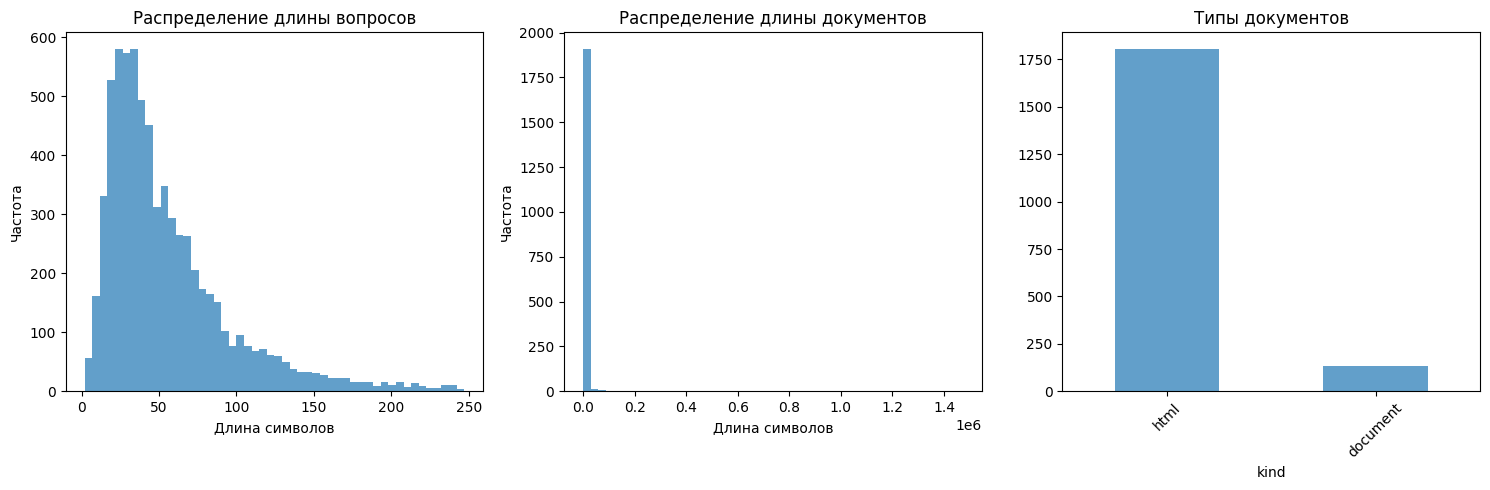

In [ ]:
# analysis_utils.py
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_data(questions_df, websites_df):
    """Анализ данных"""
    print("=== АНАЛИЗ ДАННЫХ ===")

    # Анализ вопросов
    print(f"\nВопросы:")
    print(f"Всего вопросов: {len(questions_df)}")
    questions_df['query_length'] = questions_df['query'].str.len()
    print(f"Средняя длина вопроса: {questions_df['query_length'].mean():.1f} символов")

    # Анализ документов
    print(f"\nДокументы:")
    print(f"Всего документов: {len(websites_df)}")
    websites_df['text_length'] = websites_df['text'].str.len()
    print(f"Средняя длина текста: {websites_df['text_length'].mean():.1f} символов")

    # Анализ типов документов
    if 'kind' in websites_df.columns:
        print(f"\nТипы документов:")
        print(websites_df['kind'].value_counts())

    # Визуализация
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.hist(questions_df['query_length'], bins=50, alpha=0.7)
    plt.title('Распределение длины вопросов')
    plt.xlabel('Длина символов')
    plt.ylabel('Частота')

    plt.subplot(1, 3, 2)
    plt.hist(websites_df['text_length'], bins=50, alpha=0.7)
    plt.title('Распределение длины документов')
    plt.xlabel('Длина символов')
    plt.ylabel('Частота')

    plt.subplot(1, 3, 3)
    if 'kind' in websites_df.columns:
        websites_df['kind'].value_counts().plot(kind='bar', alpha=0.7)
        plt.title('Типы документов')
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.savefig('data_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


analyze_data(questions_df, websites_df)